In [ ]:
import pandas as pd
import re
# from vader.vaderSentiment import SentimentIntensityAnalyzer
# pip install vaderSentiment
# from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
# Download the VADER lexicon
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import transformers

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving book_reviews_sample.csv to book_reviews_sample.csv


In [ ]:
data = pd.read_csv("book_reviews_sample.csv")
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [ ]:
data['reviewText_lower'] = data['reviewText'].str.lower()
data.head(2)

,index,reviewText,rating,reviewText_lower
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...


In [ ]:
data['reviewText_cleaned'] = data.apply(lambda x : re.sub(r"([^\w\s])","",x['reviewText_lower']),axis=1)
data.head(2)

,index,reviewText,rating,reviewText_lower,reviewText_cleaned
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex a sexy hot cop and the phd candidate what...


In [ ]:
vader = SentimentIntensityAnalyzer()
data['vader_Sentiment_score'] = data['reviewText_cleaned'].apply(lambda x : vader.polarity_scores(x)['compound'])
data.head(2)

,index,reviewText,rating,reviewText_lower,reviewText_cleaned,vader_Sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex a sexy hot cop and the phd candidate what...,0.9325


<Axes: xlabel='final_score'>

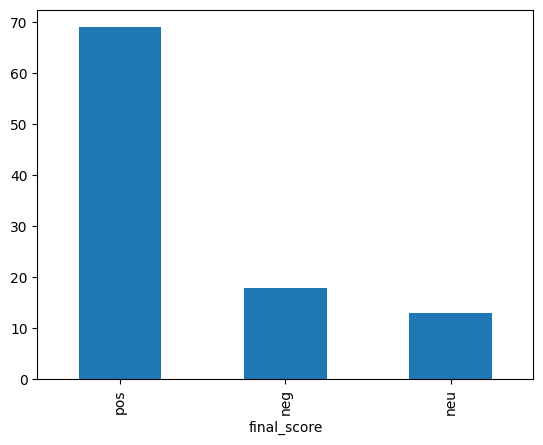

In [ ]:
bins = [-1,-0.1,0.1,1]
labels = ['neg','neu','pos']
data['final_score'] = pd.cut(data['vader_Sentiment_score'],bins,labels=labels)
data['final_score'].value_counts().plot.bar()

Sentiment Analysis using transformers

In [ ]:
from transformers import pipeline
transformer_pipeline = pipeline('sentiment-analysis')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [ ]:
trans_labels = []
for review in data['reviewText_cleaned'].values:
  temp = transformer_pipeline(review)
  sent_label = [dic['label'] for dic in temp]
  trans_labels.append(sent_label)

data['transformer_SentimentScore'] = trans_labels
data.head()

,index,reviewText,rating,reviewText_lower,reviewText_cleaned,vader_Sentiment_score,final_score,transformer_SentimentScore
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean and funny a bit busy with all the differ...,0.7684,pos,[POSITIVE]
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex a sexy hot cop and the phd candidate what...,0.9325,pos,[POSITIVE]
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing that this is a free story i read it...,0.6740,pos,[NEGATIVE]
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...,0.6652,pos,[NEGATIVE]
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,this was hands down the worse book i have ever...,-0.4767,neg,[NEGATIVE]


<Axes: xlabel='transformer_SentimentScore'>

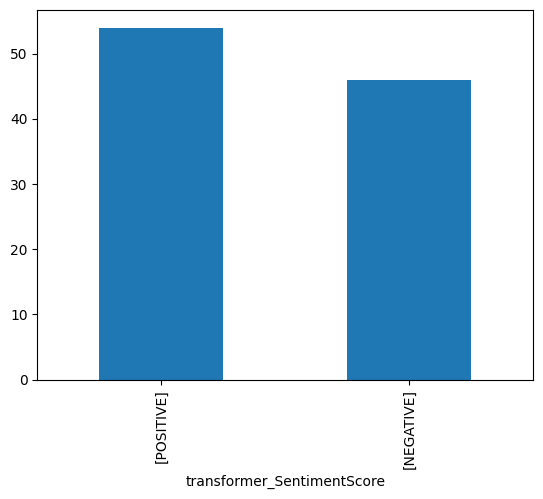

In [ ]:
data['transformer_SentimentScore'].value_counts().plot.bar()